In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df  = pd.read_csv('placement.csv')

In [5]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: xlabel='placement_exam_marks', ylabel='Count'>

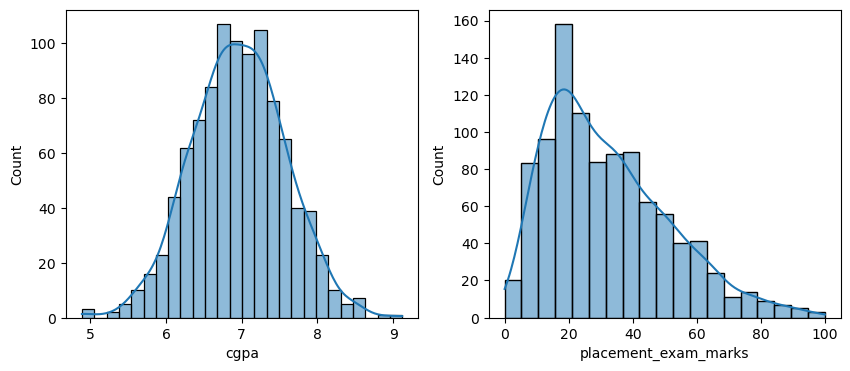

In [6]:
plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde = True )

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde = True)

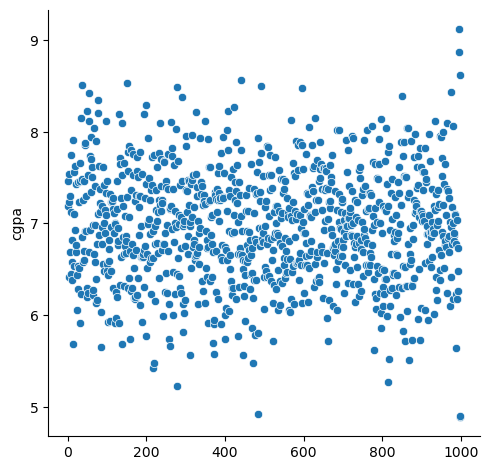

In [7]:
sns.relplot(df['cgpa'])

In [8]:
print('mean in cgpa =',df['cgpa'].mean())
print('std in cgpa  =',df['cgpa'].std())
print('min in cgpa  =',df['cgpa'].min())
print('max in cgpa  =',df['cgpa'].max())

mean in cgpa = 6.96124
std in cgpa  = 0.6158978751323894
min in cgpa  = 4.89
max in cgpa  = 9.12


In [9]:
print('max allowed = ',df['cgpa'].mean() + 3*df['cgpa'].std())
print('min allowed = ',df['cgpa'].mean() - 3*df['cgpa'].std())

max allowed =  8.808933625397168
min allowed =  5.113546374602832


In [10]:
df[(df['cgpa'] > 8.80)  |  (df['cgpa'] < 5.11 )]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [11]:
df.shape

(1000, 3)

# Trimming


In [12]:
new_df = df[(df['cgpa'] < 8.80)  & (df['cgpa'] > 5.11 )]

In [13]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


# capping

In [17]:
upper_limit = df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [16]:

df['cgpa'] = np.where(
    df['cgpa']>upper_limit,
    upper_limit,
    np.where(
        df['cgpa']<lower_limit,
        lower_limit,
        df['cgpa']
    )
)

In [19]:
df.shape

(1000, 3)

In [20]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64